# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly


# 1. Business Understanding
Problem statement: The HDB resale flat prices will often fluctuate due to factors like the town, flat type, floor area, flat model, and lease remaining. This makes it hard to predict the price of HDB flats leading to buyers overpaying or sellers overpricing their flats.

Goal: The goal is to develop a machine learning model that can accurately predict the HDB resale prices of flats in the east with data from 2017 onwards.

Machine learning approach:
The task type is supervised learning and it is a regression problem

Business impact and value:
For home buyers and sellers it can help to estimate the flat prices so that the buyers do not overpay while the sellers do not undersell. For property agents it can help to set a reasonable price.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
df = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")

In [3]:
# Convert 'month' to datetime
df['month'] = pd.to_datetime(df['month'])

# Filter the dataset to include only towns in the east
east_towns = ['BEDOK', 'TAMPINES', 'PASIR RIS', 'MARINE PARADE']
df = df[df['town'].isin(east_towns)]

# Display the first 5 rows to confirm filtering
print(df.head())

        month   town flat_type block      street_name storey_range  \
56 2017-01-01  BEDOK    2 ROOM   101  BEDOK NTH AVE 4     04 TO 06   
57 2017-01-01  BEDOK    3 ROOM   548  BEDOK NTH AVE 1     04 TO 06   
58 2017-01-01  BEDOK    3 ROOM    75     BEDOK NTH RD     07 TO 09   
59 2017-01-01  BEDOK    3 ROOM   550  BEDOK NTH AVE 1     01 TO 03   
60 2017-01-01  BEDOK    3 ROOM     1  BEDOK STH AVE 1     01 TO 03   

    floor_area_sqm      flat_model  lease_commence_date     remaining_lease  \
56            45.0        Improved                 1978  60 years 06 months   
57            68.0  New Generation                 1980  62 years 06 months   
58            59.0        Improved                 1978            60 years   
59            68.0  New Generation                 1980  62 years 05 months   
60            59.0        Improved                 1976            58 years   

    resale_price  
56      238000.0  
57      272000.0  
58      278000.0  
59      280000.0  
60      2

In [4]:
# Verify the town distribution
print(df['town'].unique())

['BEDOK' 'MARINE PARADE' 'PASIR RIS' 'TAMPINES']


In [5]:
# Save the filtered dataframe to a new CSV file
df.to_csv("Filtered_East_HDB_Resale.csv", index=False)

## 2.2 Summary Statistics

In [6]:
# Number of rows and columns
# Display the dimensions of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (36464, 11)


In [7]:
## Describe data distribution
df.describe()

,month,floor_area_sqm,lease_commence_date,resale_price
count,36464,36464.000000,36464.000000,3.646400e+04
mean,2021-11-25 13:21:04.501974528,101.469203,1990.821769,5.453857e+05
min,2017-01-01 00:00:00,38.000000,1972.000000,1.500000e+05
25%,2019-10-01 00:00:00,82.000000,1984.000000,4.100000e+05
50%,2021-11-01 00:00:00,104.000000,1988.000000,5.200000e+05
75%,2024-03-01 00:00:00,122.000000,1996.000000,6.600000e+05
max,2026-06-01 00:00:00,193.000000,2022.000000,1.400000e+06
std,NaN,26.021373,11.933838,1.757471e+05


In [8]:
# View information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36464 entries, 56 to 232028
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                36464 non-null  datetime64[ns]
 1   town                 36464 non-null  object        
 2   flat_type            36464 non-null  object        
 3   block                36464 non-null  object        
 4   street_name          36464 non-null  object        
 5   storey_range         36464 non-null  object        
 6   floor_area_sqm       36464 non-null  float64       
 7   flat_model           36464 non-null  object        
 8   lease_commence_date  36464 non-null  int64         
 9   remaining_lease      36464 non-null  object        
 10  resale_price         36464 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 3.3+ MB


In [9]:
# Check for missing values
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

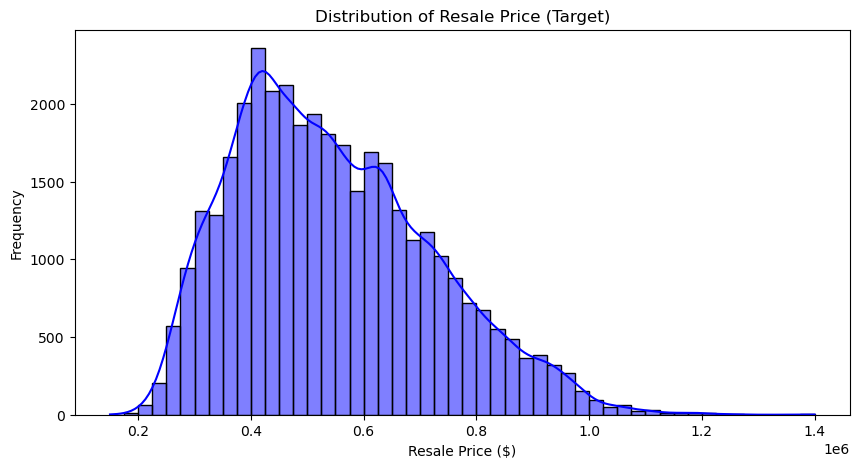

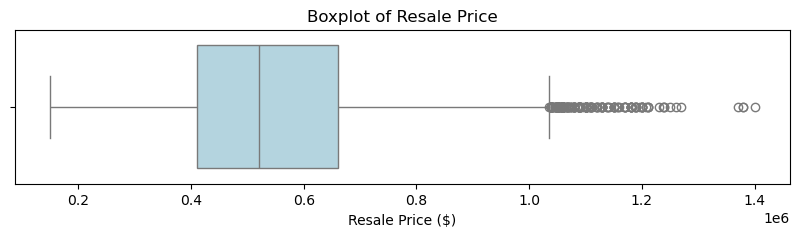

In [10]:
## Understanding distribution of target
# Plotting the histogram with KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 5))
sns.histplot(df['resale_price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Resale Price (Target)')
plt.xlabel('Resale Price ($)')
plt.ylabel('Frequency')
plt.show()

# Plotting a boxplot to check for outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['resale_price'], color='lightblue')
plt.title('Boxplot of Resale Price')
plt.xlabel('Resale Price ($)')
plt.show()

### 2.3.1.2 Understanding distribution of features

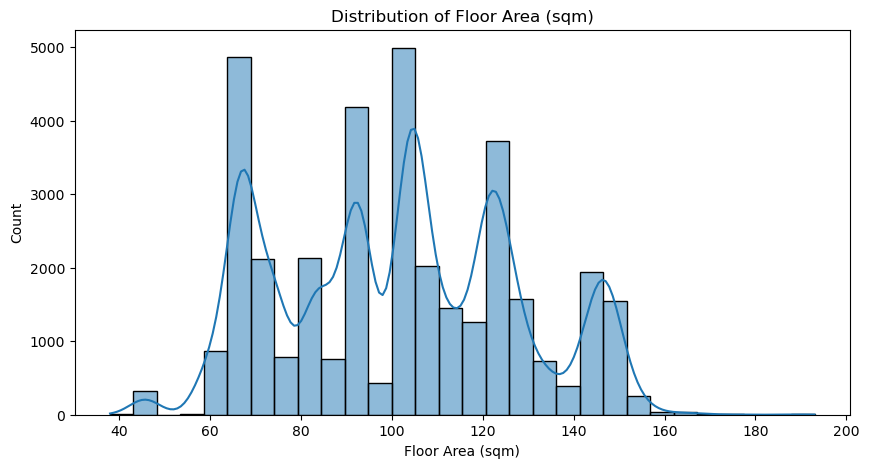

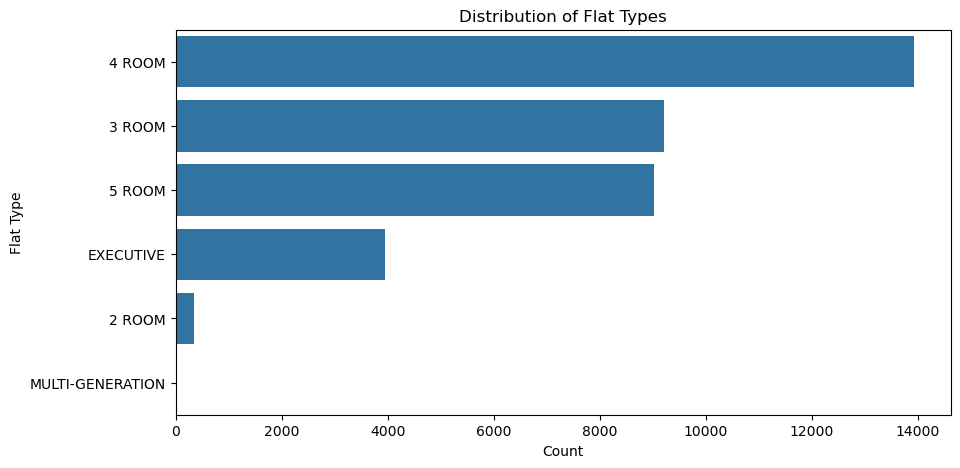

In [11]:
## Understanding distribution of features
## Understanding distribution of features
plt.figure(figsize=(10, 5))
sns.histplot(df['floor_area_sqm'], bins=30, kde=True)
plt.title('Distribution of Floor Area (sqm)')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(y=df['flat_type'], order=df['flat_type'].value_counts().index)
plt.title('Distribution of Flat Types')
plt.xlabel('Count')
plt.ylabel('Flat Type')
plt.show()

### 2.3.2 Understanding relationship between variables

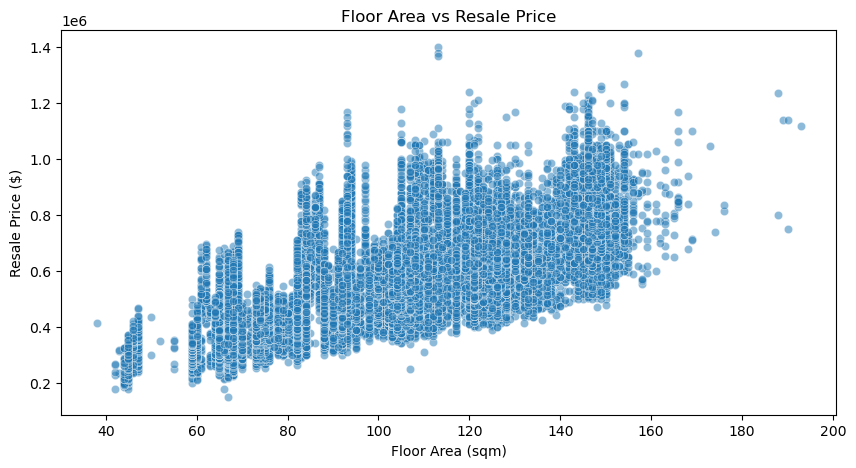

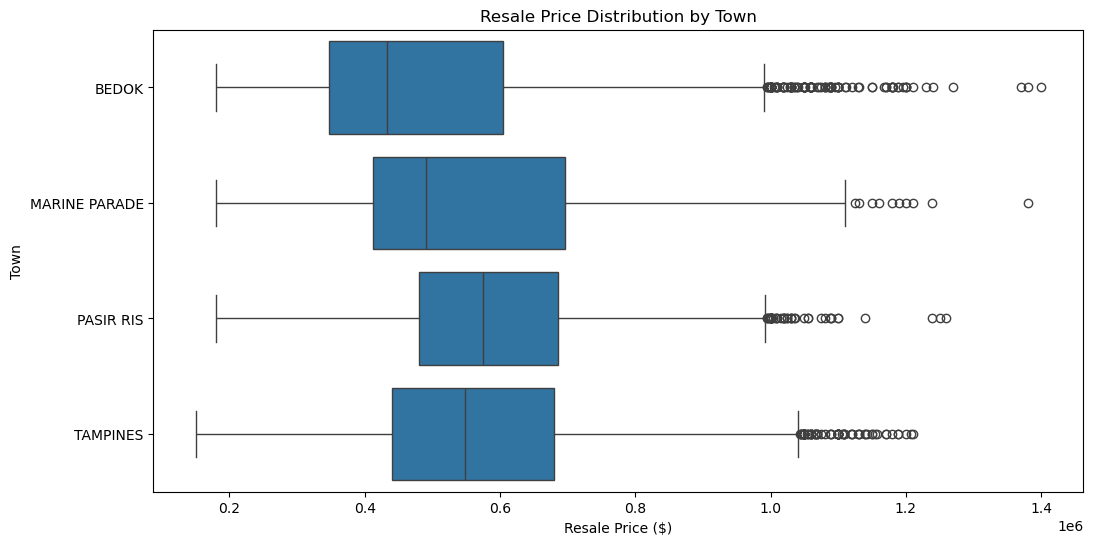

In [12]:
## Understanding relationship between variables
plt.figure(figsize=(10, 5))
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=df, alpha=0.5)
plt.title('Floor Area vs Resale Price')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='resale_price', y='town', data=df)
plt.title('Resale Price Distribution by Town')
plt.xlabel('Resale Price ($)')
plt.ylabel('Town')
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [24]:
## Clean data

# 1. Feature Engineering: Extract numerical year from 'month'
# Rationale: Scikit-learn cannot process datetime objects directly. 
# Extracting the year allows the model to learn yearly price trends.
df['transaction_year'] = df['month'].dt.year

# 2. Feature Engineering: Parse 'remaining_lease' into numerical years
# Rationale: Machine learning algorithms require numerical inputs. 
# This converts text like "60 years 06 months" into 60.5.
def parse_remaining_lease(lease_str):
    parts = str(lease_str).split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0
    return years + (months / 12.0)

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_remaining_lease)

# 3. Drop Irrelevant and Redundant Columns
# Rationale: 'block' and 'street_name' have high cardinality which can cause overfitting.
# 'month' and 'remaining_lease' are replaced by our engineered features.
# 'lease_commence_date' is highly correlated with the remaining lease, so it is redundant.
columns_to_drop = [
    'month', 
    'remaining_lease', 
    'lease_commence_date', 
    'block', 
    'street_name'
]
df_cleaned = df.drop(columns=columns_to_drop)
# Display the remaining columns to verify
print("Remaining features:", df_cleaned.columns.tolist())

# 4. One-Hot Encoding for Categorical Variables
# Rationale: Scikit-learn models only understand numbers.
# This converts categorical text (like 'town' and 'flat_type') into binary (0 or 1) columns.
categorical_cols = ['town', 'flat_type', 'storey_range', 'flat_model']
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 5. Define Features (X) and Target (y)
X = df_cleaned.drop(columns=['resale_price'])
y = df_cleaned['resale_price']

# Verify the cleaned dataset
print("Data Cleaning Complete. Features shape:", X.shape)

Remaining features: ['town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model', 'resale_price', 'transaction_year', 'remaining_lease_years']
Data Cleaning Complete. Features shape: (36464, 33)


## 3.2 Train-Test Split

In [25]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 29171 samples
Testing set size: 7293 samples


# 4. Modelling

### 4.2 Train Model

In [15]:
## Initialise and train model


# 5. Model Evaluation

In [16]:
## Evaluate model


In [17]:
## New data

## Predict


## Iterative model development


In [18]:
## Further feature engineering / feature selection